# Library

In [1]:
# Ignore the warnings
import warnings
# warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# System related and data input controls
import os

# Python path
import sys
base_folder = 'DataScience'
location_base = os.path.join(os.getcwd().split(base_folder)[0], base_folder)
location_module = [os.path.join(location_base, 'Module')] 
for each in location_module:
    if each not in sys.path:
        sys.path.append(each)

# Auto reload of library
%reload_ext autoreload
%autoreload 2

# Device Strategy
from import_KK import *
strategy, torch_device, num_gpus = DeviceStrategy()
from preprocessing_project_KK import *
from preprocessing_KK import *
from description_KK import *
from algorithm_machinelearning_KK import *
from algorithm_deeplearning_KK import *
from evaluation_KK import *
from visualization_KK import *

JAVA_HOME: /usr/lib/jvm/java-17-openjdk-amd64
Operation Machine:  x86_64
Operation Platform:  64bit
OS Type:  Linux
OS Version:  7.0.0-31-generic
Python Version:  3.12.14 (main, Sep  2 2026, 23:27:36) [GCC 15.3.0]
🎯 [PyTorch] Default Device Assigned to GPU 1 (cuda:1)
🎯 [cuML] Target Device Assigned to GPU 1 (cuda:1)
🚀 [Hardware Acceleration] NVIDIA RAPIDS cuML v26.08.00 (GPU 가속) 활성화



=========== Device Strategy ===========
Detected GPUs:
 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
TF isolated to CPU (All 24GB VRAM reserved exclusively for PyTorch/XGBoost)
======= GPU / CUDA / STATUS ========
Cuda Ready?         True
CUDA Version:       12.5.1
cuDNN Version:      9

TF Version:         2.20.0
Keras Version:      3.15.1

------- Torch Check ----------------
Torch CUDA Available: True
Torch Version:        2.14.0+cu130
Torch CUDA Version:   13.0
Torch cuDNN Version:  92501
Torch GPUs Available: 2
Use the GPU [0]:    NVIDIA GeForce RTX 3090 (Index: 0)
Use the GPU [1]:    NVIDIA GeForce RTX 3090 (Index: 1)

KRX 로그인 실패: KRX_ID 또는 KRX_PW 환경 변수가 설정되지 않았습니다.


# Hyperparameters

In [2]:
# Data
# FOLDER_GDM, FOLDER_GDS = get_google_drivelocation(gdrive='z', glocation=os.path.join('Research', 'SavedData', 'NTIS'))
# FOLDER_LOCATION = FOLDER_GDM
FOLDER_LOCATION = os.path.join('.', 'Data')
FILENAME = 'ebitda_margin_model_ready_2016_2025_JJ_260804.csv'
FILE_LOCATION = os.path.join(FOLDER_LOCATION, FILENAME)
LANGUAGE = 'en'

# Data Filtering
YEAR_MIN = 2016
YEAR_MAX = 2025
AGE_MIN = None
AGE_MAX = None
GENDER = 'all' # 'male', 'female'

# Preprocessing
Y_colname = 'target__EBITDA대매출액_t1'
Year_colname = None
T_colname = None
X_reverse = None
X_handle_nonres = False
X_nonres_col = None
X_nullmax = None
X_nullmin = None
X_dummy = None
X_encoding = None
X_delYrelated = None
X_del = None
X_delete = (X_delYrelated or []) + (X_del or [])
WINSORIZE_LIMITS = (0.01, 0.01)
# WINSORIZE_LIMITS = None

TEST_SIZE = 'Time'
YEAR_VAL, YEAR_TEST = 1, 1 # Execute when TEST_SIZE = 'Time'
IMPUTE_METHOD = 'mice' # 'knn', 'mice', 'median'
RANDOM_STATE = 123
SAMPLING_METHOD = None    # 'auto'
# LABEL_LIST = ['Non-Violence', 'Violence']
LABEL_LIST = None

# Model
ALGO_NAMES_ML = ['Linear Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']
# ALGO_NAMES_ML = ['LightGBM', 'CatBoost']
ALGO_NAMES_DL = ['MLP', 'CNN', 'TabNet']
# ALGO_NAMES_DL = ['TabNet']
## Common
TUNE_TRIALS_ML = 50
TUNE_TRIALS_DL = 10
CV_SPLITS = 5
TUNE_METRIC_ML = 'RMSE' # Default('auto'): 'F1-score', 'RMSE' - 접두사 없어도 자동으로 validation set 기준으로 판단TUNE_METRIC = 'auto'
TUNE_METRIC_DL = 'val_RMSE' # 'AUC', 'Accuracy', 'F1-score', 'loss', 'val_AUC', 'val_Accuracy', 'val_F1-score', 'val_loss'
METRIC_FINAL = "RMSE"
## DL
CLASS_WEIGHT_METHOD = 'class' # class, sample, user_defined_dict
tf.random.set_seed(123)
NODE_MLP = [256, 512, 256, 128, 64]
NODE_CNN = [128, 256, 512]
VALIDATION_SPLIT = 0.2
if VALIDATION_SPLIT != None:
    VALIDATION_DATA = None
BATCH_SIZE = 512
EPOCHS = 100
VERBOSE = 0
## XAI
SHAP = True
INTERACTION = True
INTERACTION_SAMPLES = 5000
INTERACTION_BATCH = 100
X_TOP_DISPLAY = 50
## Causal Inference
if T_colname != None:
    CAUSAL_CRITERION = 'het'
    CAUSAL_HONEST = True
    CAUSAL_INFERENCE = True

# Save
SAVE_NAME_PREDSTATTR = 'DescriptiveStatistics_BinaryPredTrain.csv'
SAVE_NAME_PREDSTATTE = 'DescriptiveStatistics_BinaryPredTest.csv'
SAVE_NAME_ML = 'Performance_ML'
SAVE_NAME_DL = 'Performance_DL'
SAVE_NAME_PERFORMANCE = 'Performance.csv'
SAVE_FOLDER_BASE = os.path.join('.', 'Result', 'Base')
SAVE_FOLDER_TEST = os.path.join('.', 'Result', 'Test')

# Data Preprocessing

In [3]:
# Data Loading
df_raw = pd.read_csv(os.path.join(FOLDER_LOCATION, FILENAME))

In [4]:
# Preprocessing Data
df_prep, YEAR_COLNAME, FEATURE_BLOCKS = preprocessing_CarbonFinance(
    df_raw,
    year_min=YEAR_MIN, 
    year_max=YEAR_MAX,
    Y_colname=Y_colname,          
    drop_firm_dummies=True,        
    create_lags=True,          
    X_delete=X_del
)

# Preprocessing for Modeling
X_train, X_test, Y_train, Y_test, \
TASK, df_final, X_colname, \
CV_SPLITS, LABEL_LIST = preprocessing_modeling_KK(
    df_raw=df_prep, Y_colname=Y_colname, Year_colname=YEAR_COLNAME, X_dummy=X_dummy, 
    winsorize_limits=WINSORIZE_LIMITS,
    test_size=TEST_SIZE, year_val=YEAR_VAL, year_test=YEAR_TEST,
    impute_method=IMPUTE_METHOD,
    sampling_method=SAMPLING_METHOD,
    label_list=LABEL_LIST,
)


 [PHASE 1] Preprocessing: Margin Delta Target & Feature Block Curation
 Initial Shape: (6114, 1430)
▶ Sorted Panel: By [meta__종목코드] & [meta__feature_year]
▶ Generating Dynamic Lags for 13 features...
   ▷ Shape after Lag Generation: (6114, 1456)
▶ Target Year Filter: 2016 ~ 2025 (Remaining Rows: 6,114)
▶ In-place Target Updated to Margin Delta: 'target__EBITDA대매출액_t1' (Mean: -0.0014, Std: 0.0594)
▶ Dropped Individual Firm Dummies: 613 columns
▶ Dropped Unused Meta Columns (Preserved: ['meta__target_year']): ['meta__feature_year', 'meta__종목코드', 'meta__split']

[Feature Block Curation Summary (MECE)]
  ▷ Block1_Financial_Control  :  157 features
  ▷ Block2_Carbon_Risk        :  125 features
  ▷ Block3_Social_Governance  :   36 features
  ▷ Block4_Industry_Macro     :  520 features
  ▷ Total Allocated / Total Available: 838 / 838 (Orphan: 0)


Completed Domain Preprocessing in 0.13s
Final Data Shape: (6114, 840) | Assigned YEAR_COLNAME: 'meta__target_year'


▶ Detected Task Type: [ REGRE

# Modeling

## Machine Learning

In [ ]:
# ML Modeling
results_ML, scores_ML = modeling_ML(
    algos=ALGO_NAMES_ML,
    X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test,
    task=TASK,
    X_colname=X_colname,
    params=None, # 특정 알고리즘
    tune_trials=TUNE_TRIALS_ML, # 최적화 여부
    cv_splits=CV_SPLITS,
    tune_metric=TUNE_METRIC_ML,
    X_top_display=X_TOP_DISPLAY, 
    label_list=LABEL_LIST,
    random_state=RANDOM_STATE,
)


## Deep Learning

In [ ]:
# DL Modeling
results_DL, scores_DL = modeling_DL(
    algos=ALGO_NAMES_DL,
    X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test,
    task=TASK,
    class_weight_method=CLASS_WEIGHT_METHOD,
    node_list=None, # 특정 알고리즘
    validation_split=VALIDATION_SPLIT,
    validation_data=VALIDATION_DATA,
    tune_trials=TUNE_TRIALS_DL, # 최적화 여부
    cv_splits=CV_SPLITS,
    tune_metric=TUNE_METRIC_DL,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    earlystop_patient=None,
    shap_display=False,
    label_list=LABEL_LIST,
    random_state=RANDOM_STATE,
)


# Performance Summary

In [5]:
# Result Summary
folder_location = os.path.join(os.getcwd(),'Result')
scores = prediction_summary(
    folder_location=folder_location, 
    algonames=ALGO_NAMES_ML + ALGO_NAMES_DL,
    save_name=SAVE_NAME_PERFORMANCE,
)

### Performance Summary : 8 Algorithms ###

>>> [Train set] Performance Comparison


,Algorithm,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,Linear Regression,0.4750,0.2257,0.4276,0.4276,0.4368,0.4368,-61.6053
1,Random Forest,0.0446,0.0020,0.0283,0.0283,0.0165,0.0165,0.4480
2,XGBoost,0.0134,0.0002,0.0086,0.0086,0.0054,0.0054,0.9503
3,LightGBM,0.0325,0.0011,0.0222,0.0222,0.0150,0.0150,0.7061
4,CatBoost,0.0383,0.0015,0.0268,0.0268,0.0180,0.0180,0.5939
5,MLP,0.0595,0.0035,0.0393,0.0393,0.0240,0.0240,0.0180
6,CNN,0.0600,0.0036,0.0383,0.0383,0.0220,0.0220,0.0013
7,TabNet,0.0611,0.0037,0.0400,0.0400,0.0242,0.0242,-0.0356



>>> [Validation(CV)] Performance Comparison


,Algorithm,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,Linear Regression,0.5261,0.2768,0.4973,0.4973,0.5059,0.5059,-74.1538
1,Random Forest,0.0569,0.0032,0.0352,0.0352,0.0194,0.0194,0.1202
2,XGBoost,0.0560,0.0031,0.0354,0.0354,0.0188,0.0188,0.1471
3,LightGBM,0.0566,0.0032,0.0359,0.0359,0.0206,0.0206,0.1303
4,MLP,0.0615,0.0038,0.0399,0.0399,0.0234,0.0234,-0.0268
5,CNN,0.0605,0.0037,0.0376,0.0376,0.0197,0.0197,0.0049
6,TabNet,0.0611,0.0037,0.0393,0.0393,0.0232,0.0232,-0.0150



>>> [Test set] Performance Comparison


,Algorithm,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,Linear Regression,0.3446,0.1188,0.3123,0.3123,0.3261,0.3261,-40.3586
1,Random Forest,0.0505,0.0025,0.0311,0.0311,0.0178,0.0178,0.1120
2,XGBoost,0.0508,0.0026,0.0317,0.0317,0.0191,0.0191,0.1023
3,LightGBM,0.0515,0.0027,0.0318,0.0318,0.0183,0.0183,0.0767
4,CatBoost,0.0504,0.0025,0.0314,0.0314,0.0188,0.0188,0.1156
5,MLP,0.0570,0.0032,0.0370,0.0370,0.0220,0.0220,-0.1308
6,CNN,0.0535,0.0029,0.0327,0.0327,0.0177,0.0177,0.0051
7,TabNet,0.0548,0.0030,0.0348,0.0348,0.0207,0.0207,-0.0459



>>> [Entire population] Performance Comparison


,Algorithm,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,Linear Regression,0.4636,0.2149,0.4160,0.4160,0.4229,0.4229,-59.8534
1,Random Forest,0.0452,0.0020,0.0286,0.0286,0.0165,0.0165,0.4207
2,XGBoost,0.0205,0.0004,0.0109,0.0109,0.0059,0.0059,0.8811
3,LightGBM,0.0349,0.0012,0.0232,0.0232,0.0153,0.0153,0.6548
4,CatBoost,0.0396,0.0016,0.0272,0.0272,0.0181,0.0181,0.5549
5,MLP,0.0592,0.0035,0.0390,0.0390,0.0238,0.0238,0.0061
6,CNN,0.0594,0.0035,0.0378,0.0378,0.0216,0.0216,0.0019
7,TabNet,0.0605,0.0037,0.0395,0.0395,0.0240,0.0240,-0.0362


# Best Model Prediction

▶ Searching Directory: /workspace/DataScience/DIVE/Project/CO2XAI/Model
Loading Model: CatBoost
   - File: best_model_CatBoost_20260917_062539.pkl
   - Successfully Loaded.
[CatBoost] 모델 내부 변수명이 성공적으로 수정되었습니다.
Performance: 


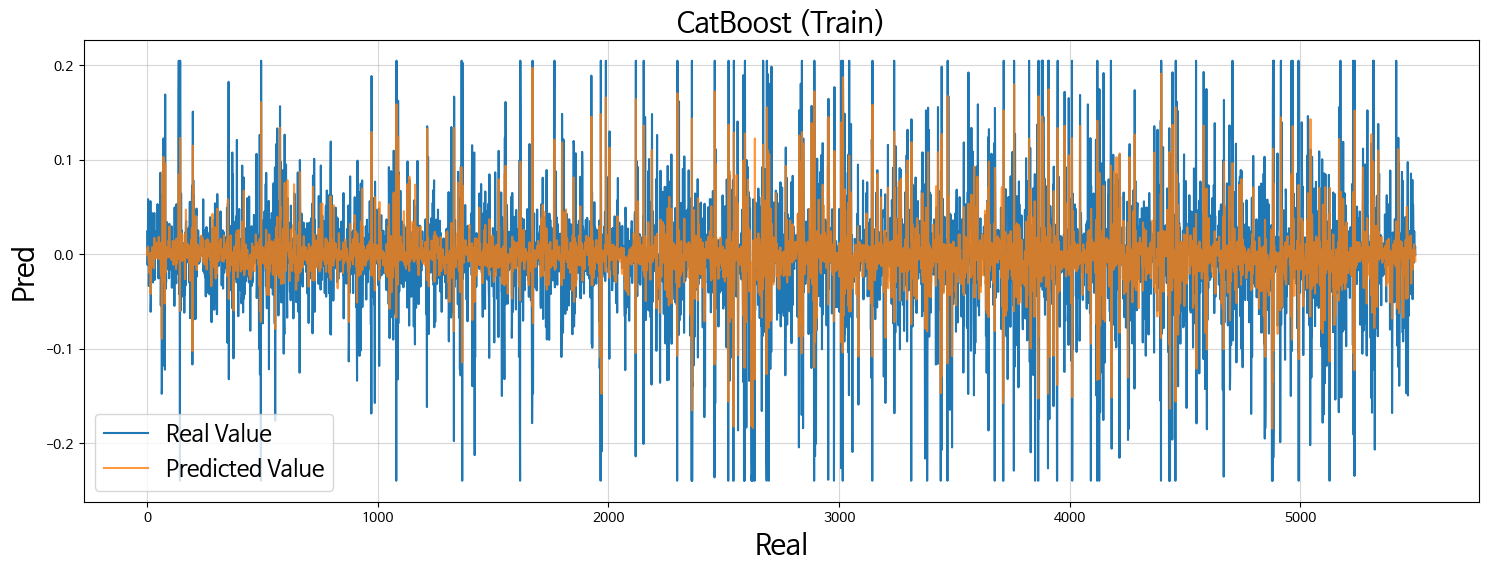

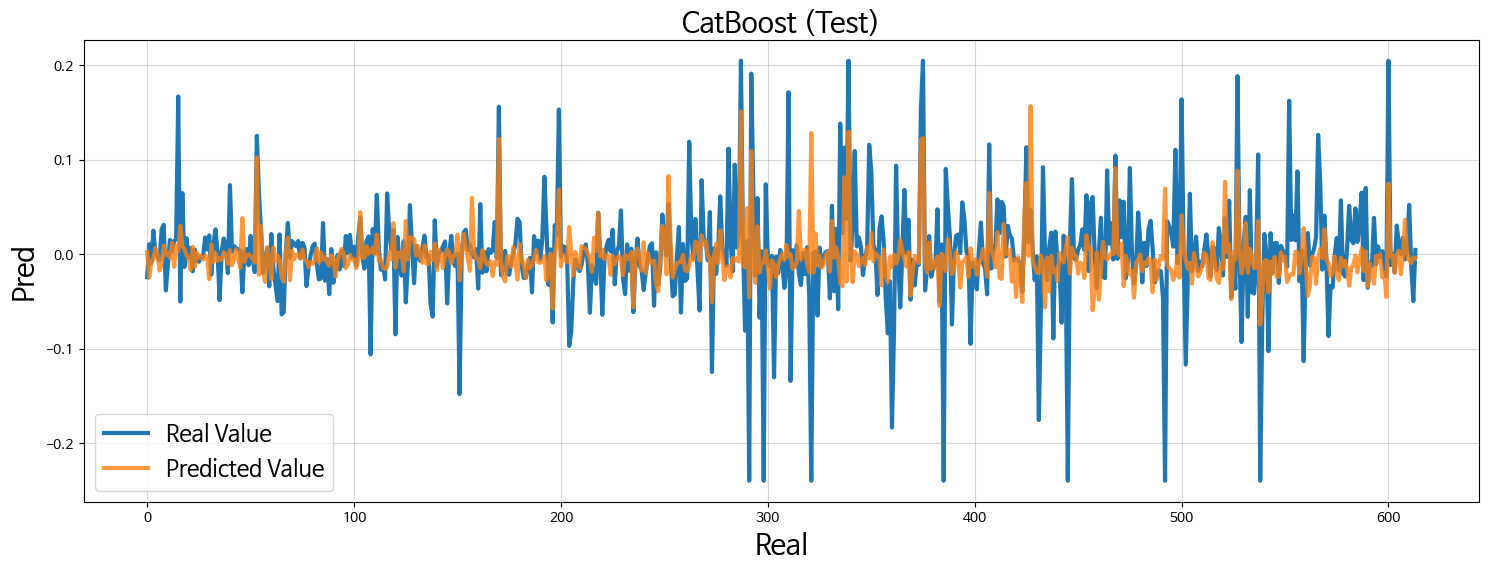

,Algorithm,Dataset,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,R2
0,CatBoost,Train set,0.0382,0.0015,0.0267,0.0267,0.0180,0.0180,0.5953
1,CatBoost,Test set,0.0504,0.0025,0.0314,0.0314,0.0188,0.0188,0.1156
2,CatBoost,Entire population,0.0396,0.0016,0.0272,0.0272,0.0181,0.0181,0.5562


Saved: ./Result/Screening_Report_CatBoostRegressor.csv

   [CatBoostRegressor] Feature Screening Report (Normalized to 100%)
>>> [Cumulative Importance >= 99.0%] (Delete Count: 659)
삭제변수명: ['indicator__배출권_참여여부', 'num__총매출_백만USD', 'cat__KSIC세분류_11차_C21300.의료용품_및_기타_의약_관련제품_제조업', 'cat__KSIC중분류_11차_C20000.화학_물질_및_화학제품_제조업', 'num__부가가치(종업원1인당)', 'cat__NICS산업분류_N30302.개인용품', 'cat__KSIC소분류_11차_C26100.반도체_제조업', 'cat__주식업종_QGS18P.의료·정밀기기', 'missing__missingindicator_기말발행주식수_보통주', 'cat__NICS산업분류_N35101.헬스케어_장비와_용품', 'cat__Scope1자료출처_Value_summed_up_from_data_provided_in_Environmental/CSR', 'missing__missingindicator_재고자산회전율2', 'cat__Scope2사업장간접보고추정구분_추정치', 'missing__missingindicator_평균시가총액_보통주우선주', 'missing__missingindicator_Scope3협력사간접배출량_tCO2e', 'missing__missingindicator_기말시가총액_보통주우선주', 'cat__Scope1보고추정구분_보고값', 'missing__missingindicator_종업원수증가율', 'num__배출권_추가할당량', 'cat__Trucost산업_Health_Care_Equipment_and_Supplies', 'num__기말시가총액', 'missing__missingindicator_매출원가_연결', 'num__총수익_연결', 'missin

,Feature,Feature Importance (Gini/Gain),Importance (%),Cumulative Importance (%)
0,num__fe_영업이익_매출,7.7808,7.7808,7.7808
1,num__EBITDA대매출액,7.3181,7.3181,15.0989
2,num__EBITDA대매출액__diff1,3.7667,3.7667,18.8656
3,num__총자본회전율,3.1114,3.1114,21.9770
4,num__EBITDA대매출액__lag1,3.0260,3.0260,25.0031
...,...,...,...,...
833,cat__KSIC중분류_11차_C25000.금속_가공제품_제조업,0.0000,0.0000,100.0000
834,cat__KSIC중분류_11차_C24000.1차_금속_제조업,0.0000,0.0000,100.0000
835,cat__KSIC중분류_11차_C23000.비금속_광물제품_제조업,0.0000,0.0000,100.0000
836,cat__주식업종_QGS14P.비금속,0.0000,0.0000,100.0000


In [6]:
# Model Loaded
if METRIC_FINAL in ['RMSE']:
    best_scoreidx = np.argmin(scores[scores.Dataset=='Test set'][METRIC_FINAL])
else:
    best_scoreidx = np.argmax(scores[scores.Dataset=='Test set'][METRIC_FINAL])
BEST_ALGO = scores[scores.Dataset=='Test set'].iloc[best_scoreidx]['Algorithm']
BEST_MODEL, BEST_PARAMS = Loading_ModelBestParams(algo_name=BEST_ALGO)
OPTIMAL_THRESHOLD = BEST_PARAMS.get('optimal_threshold', 0.5)
if BEST_ALGO in ['MLP', 'CNN', 'TabNet']:
    KERAS = True
else:
    KERAS = False
    BEST_MODEL = modeling_featurename(BEST_MODEL, BEST_ALGO, X_colname)    

# Performance Evaluation
if METRIC_FINAL in ['RMSE']:
    Scores_Test = prediction_reg(BEST_MODEL, X_train, Y_train, X_test, Y_test,
                                 ALGO_NAME=BEST_ALGO, keras=KERAS)
else:
    Scores_Test = prediction_class(BEST_MODEL, X_train, Y_train, X_test, Y_test,
                                   threshold=OPTIMAL_THRESHOLD,
                                   LABEL_LIST=LABEL_LIST, ALGO_NAME=BEST_ALGO, keras=KERAS)
display(Scores_Test)

# Feature Importance
df_importance = modeling_featureimportance(BEST_MODEL, [0.5, 0.75, 0.9, 0.95, 0.99])
display(df_importance)

# Explanation

[Auto-Config] Detected Algorithm: CatBoost | Type: Tree | Link: logit
[SHAP] Pipeline 객체가 감지되어 내부 스케일러로 데이터를 자동 변환합니다.
Loading existing SHAP values: ./Model/shap_values_CatBoost_20260917_080934.pkl
[Success] Loaded SHAP value feature names have been updated in-memory!
Loading existing SHAP interaction values: ./Model/shap_intervalues_CatBoost_20260917_081843.pkl

[Train Dataset Contribution Calculation]: 2026-09-17 10:28:55.401660
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|██████████| 838/838 [00:00<00:00, 3816.38it/s]


,Feature,Importance,Importance Percentage,Contribution Range,"Ground Truth Correlation (Y, X)","Prediction Correlation (Y_hat, X)","Total Contribution Correlation (Y_shap, X)","Total Contribution Spearman Correlation (Y_shap, X)","Pure Main Effect Correlation (Y_pure, X)",Feature,Importance,Importance Percentage,Contribution Range,"Ground Truth Correlation (Y, X)","Prediction Correlation (Y_hat, X)","Total Contribution Correlation (Y_shap, X)","Total Contribution Spearman Correlation (Y_shap, X)","Pure Main Effect Correlation (Y_pure, X)"
0,num__fe_운영탄소집약도_변화,0.0011,1.5919,0.0023,0.0256,0.0431,0.3037,0.5368,NaN,num__EBITDA대매출액,0.0047,7.0137,0.0094,-0.2390,-0.4251,-0.7257,-0.9377,NaN
1,num__fe_판관비율,0.0011,1.5842,0.0021,-0.0132,-0.0393,0.4492,0.6762,NaN,num__fe_영업이익_매출,0.0045,6.6864,0.0103,-0.2630,-0.4665,-0.8704,-0.9018,NaN
2,num__총자본회전율,0.0010,1.4523,0.0017,0.0244,0.0602,0.3140,0.3192,NaN,num__영업이익손실_연결,0.0016,2.3382,0.0030,-0.0704,-0.1084,-0.4392,-0.7076,NaN
3,num__fe_signed_log1p_연간급여총액,0.0010,1.4397,0.0040,0.0159,0.0301,0.5925,0.6125,NaN,num__EBITDA대매출액__lag1,0.0015,2.2239,0.0030,-0.1588,-0.2813,-0.7004,-0.7958,NaN
4,num__협의_거래대금_억원,0.0008,1.1583,0.0015,0.0381,0.0760,0.7462,0.7990,NaN,num__경매_거래대금_억원,0.0012,1.7425,0.0025,-0.0389,-0.0771,-0.7964,-0.7323,NaN



[Test Dataset Contribution Calculation]: 2026-09-17 10:28:58.770645
Feature Total Contribution (Calculating Metrics)...
Feature Contribution Direction (Calculating Pearson & Spearman)...


Calculating 1D Directions: 100%|██████████| 838/838 [00:00<00:00, 7173.10it/s]


,Feature,Importance,Importance Percentage,Contribution Range,"Ground Truth Correlation (Y, X)","Prediction Correlation (Y_hat, X)","Total Contribution Correlation (Y_shap, X)","Total Contribution Spearman Correlation (Y_shap, X)","Pure Main Effect Correlation (Y_pure, X)",Feature,Importance,Importance Percentage,Contribution Range,"Ground Truth Correlation (Y, X)","Prediction Correlation (Y_hat, X)","Total Contribution Correlation (Y_shap, X)","Total Contribution Spearman Correlation (Y_shap, X)","Pure Main Effect Correlation (Y_pure, X)"
0,num__총자본회전율,0.0010,1.6374,0.0018,-0.0256,0.0360,0.3329,0.3156,0.4027,num__fe_영업이익_매출,0.0043,6.8869,0.0098,-0.2144,-0.6941,-0.8702,-0.9104,-0.8861
1,num__fe_판관비율,0.0010,1.5675,0.0020,0.0029,-0.0075,0.2772,0.6037,0.7952,num__EBITDA대매출액,0.0043,6.8380,0.0086,-0.2192,-0.6256,-0.7484,-0.9462,-0.8133
2,num__협의_거래대금_억원,0.0009,1.5070,0.0014,0.0006,0.0424,0.2329,-0.0103,0.5503,num__영업이익손실_연결,0.0016,2.5983,0.0033,-0.0710,-0.1503,-0.3708,-0.7473,-0.5097
3,num__fe_운영탄소집약도_변화,0.0009,1.4991,0.0021,-0.0069,0.0766,0.4018,0.3708,0.3126,num__EBITDA대매출액__lag1,0.0015,2.3660,0.0029,-0.1360,-0.3568,-0.7874,-0.7983,-0.8762
4,num__경쟁_거래량_천톤,0.0008,1.2373,0.0014,-0.0006,-0.0424,0.1142,0.2560,0.1878,num__경매_거래량_천톤,0.0012,2.0008,0.0018,-0.0006,-0.0424,-0.3730,-0.4987,-0.6878



[Train Dataset Beeswarm Visualization]: 2026-09-17 10:28:59.309666
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


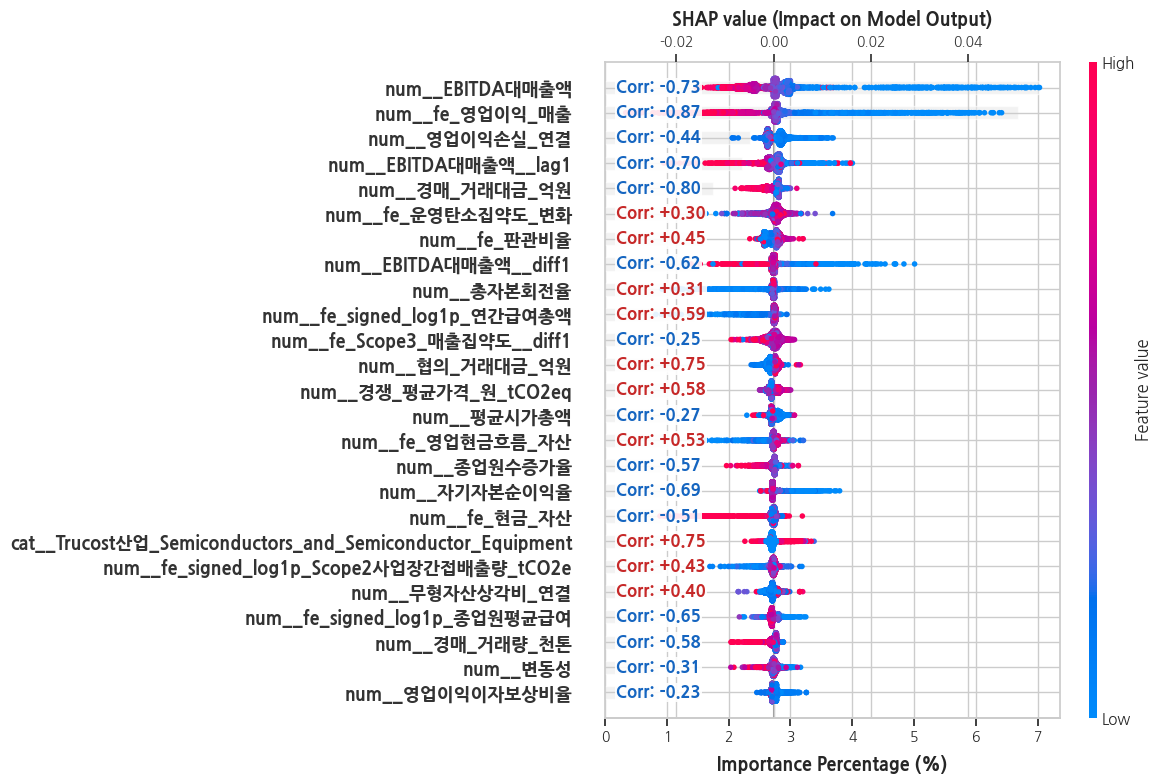


[Test Dataset Beeswarm Visualization]: 2026-09-17 10:28:59.895505
Total Explanation (Beeswarm + Importance Percentage & Correlation Bar)...


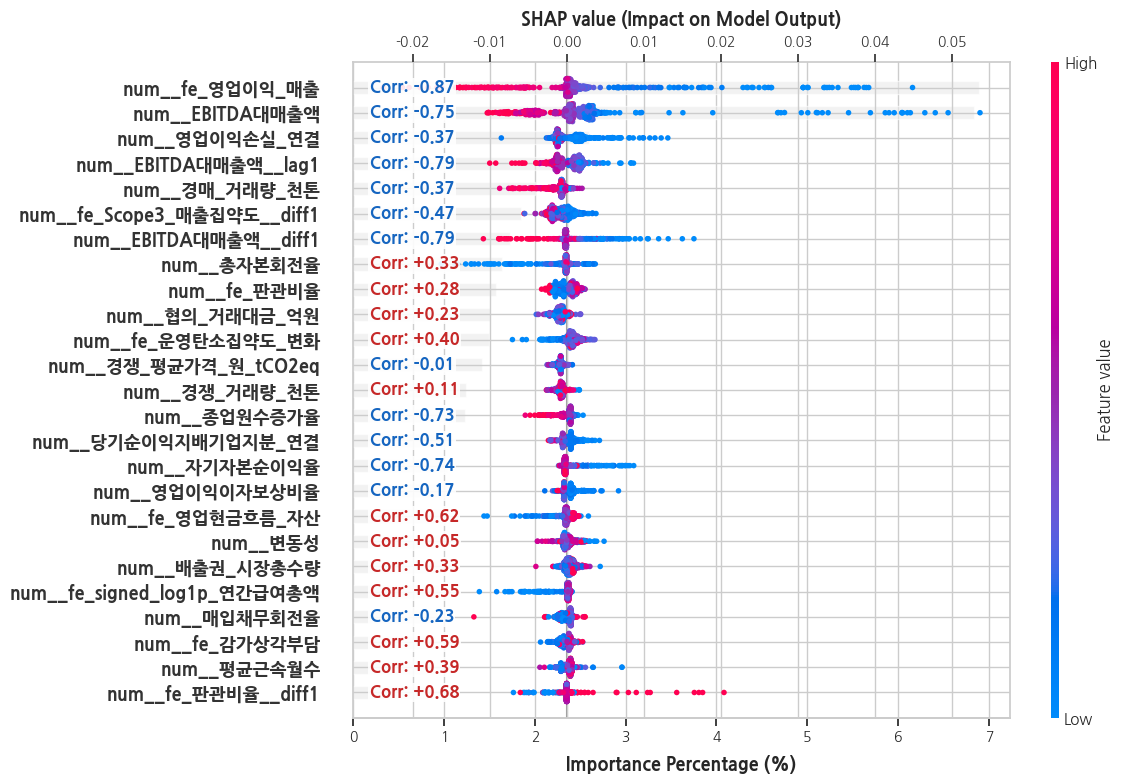


[Test Dataset Interaction]: 2026-09-17 10:29:00.176405
Feature Interactive Contribution...


Calculating Correlations: 100%|██████████| 838/838 [00:07<00:00, 118.43it/s]


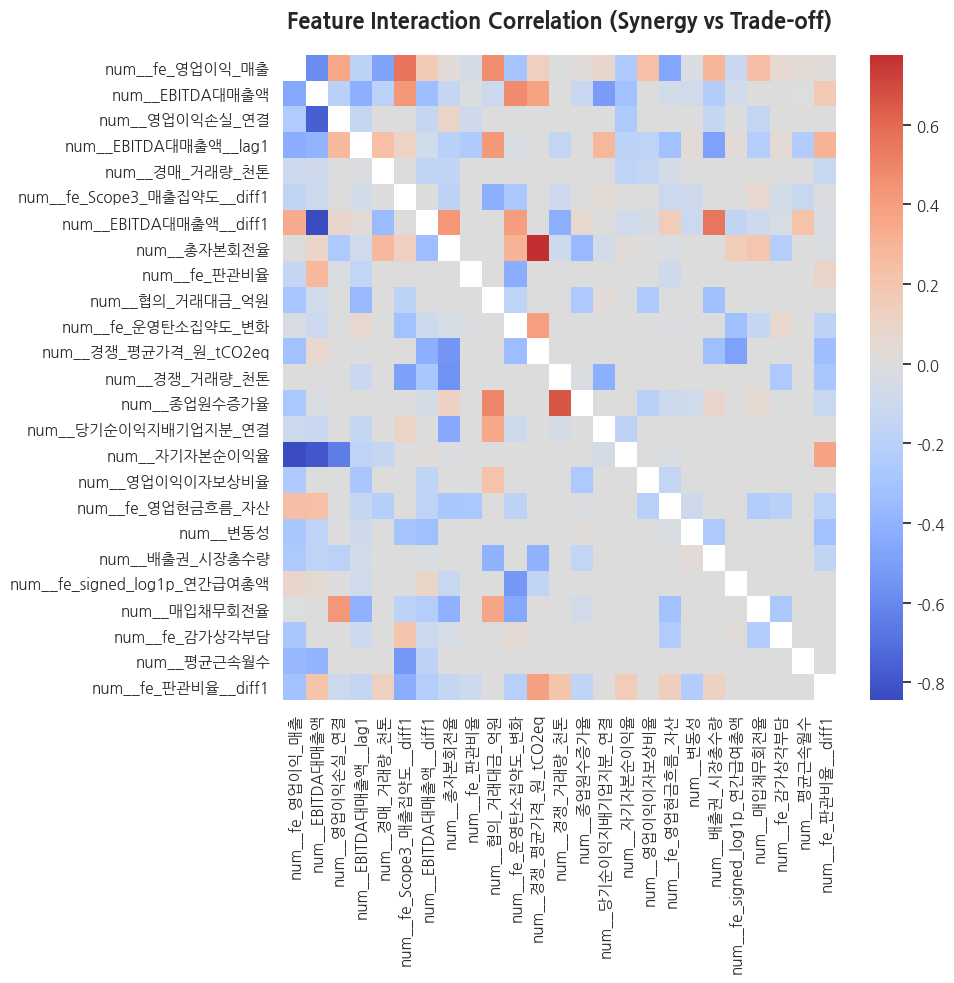


💡 Top 25 Feature Interaction Pairs (Impact Size & Direction)


,Feature 1,Feature 2,Impact Size (Magnitude),Interaction Share (%),Cumulative Share (%),Interaction Correlation,Relationship
0,num__fe_영업이익_매출,num__영업이익손실_연결,0.0014,0.9700,0.9700,0.3646,Synergy (+)
1,num__fe_영업이익_매출,num__EBITDA대매출액,0.0007,0.4700,1.4400,-0.5782,Trade-off (-)
2,num__영업이익손실_연결,num__매출채권_연결,0.0007,0.4600,1.9000,-0.4976,Trade-off (-)
3,num__fe_판관비율,num__fe_판관비율__lag1,0.0006,0.4500,2.3600,-0.7775,Trade-off (-)
4,num__경매_거래량_천톤,cat__Trucost산업_Semiconductors_and_Semiconductor_Equipment,0.0006,0.4100,2.7700,-0.0498,Neutral
5,num__EBITDA대매출액__lag1,num__경매_거래량_천톤,0.0006,0.4100,3.1800,0.2389,Synergy (+)
6,num__EBITDA대매출액,num__무형자산계_연결,0.0005,0.3600,3.5400,0.3871,Synergy (+)
7,num__경쟁_거래대금_억원,num__fe_유무형리스증가_자산,0.0005,0.3300,3.8700,-0.5221,Trade-off (-)
8,num__EBITDA대매출액,num__fe_signed_log1p_Scope1직접배출량_tCO2e,0.0004,0.3100,4.1900,-0.3947,Trade-off (-)
9,num__fe_영업이익_매출,num__매출채권_연결,0.0004,0.3100,4.5000,-0.0199,Neutral



[Test Dataset Sensitivity Analysis]: 2026-09-17 10:29:16.723369
Sensitivity Analysis (ICE & PDP Plot) for Top 25 Features...


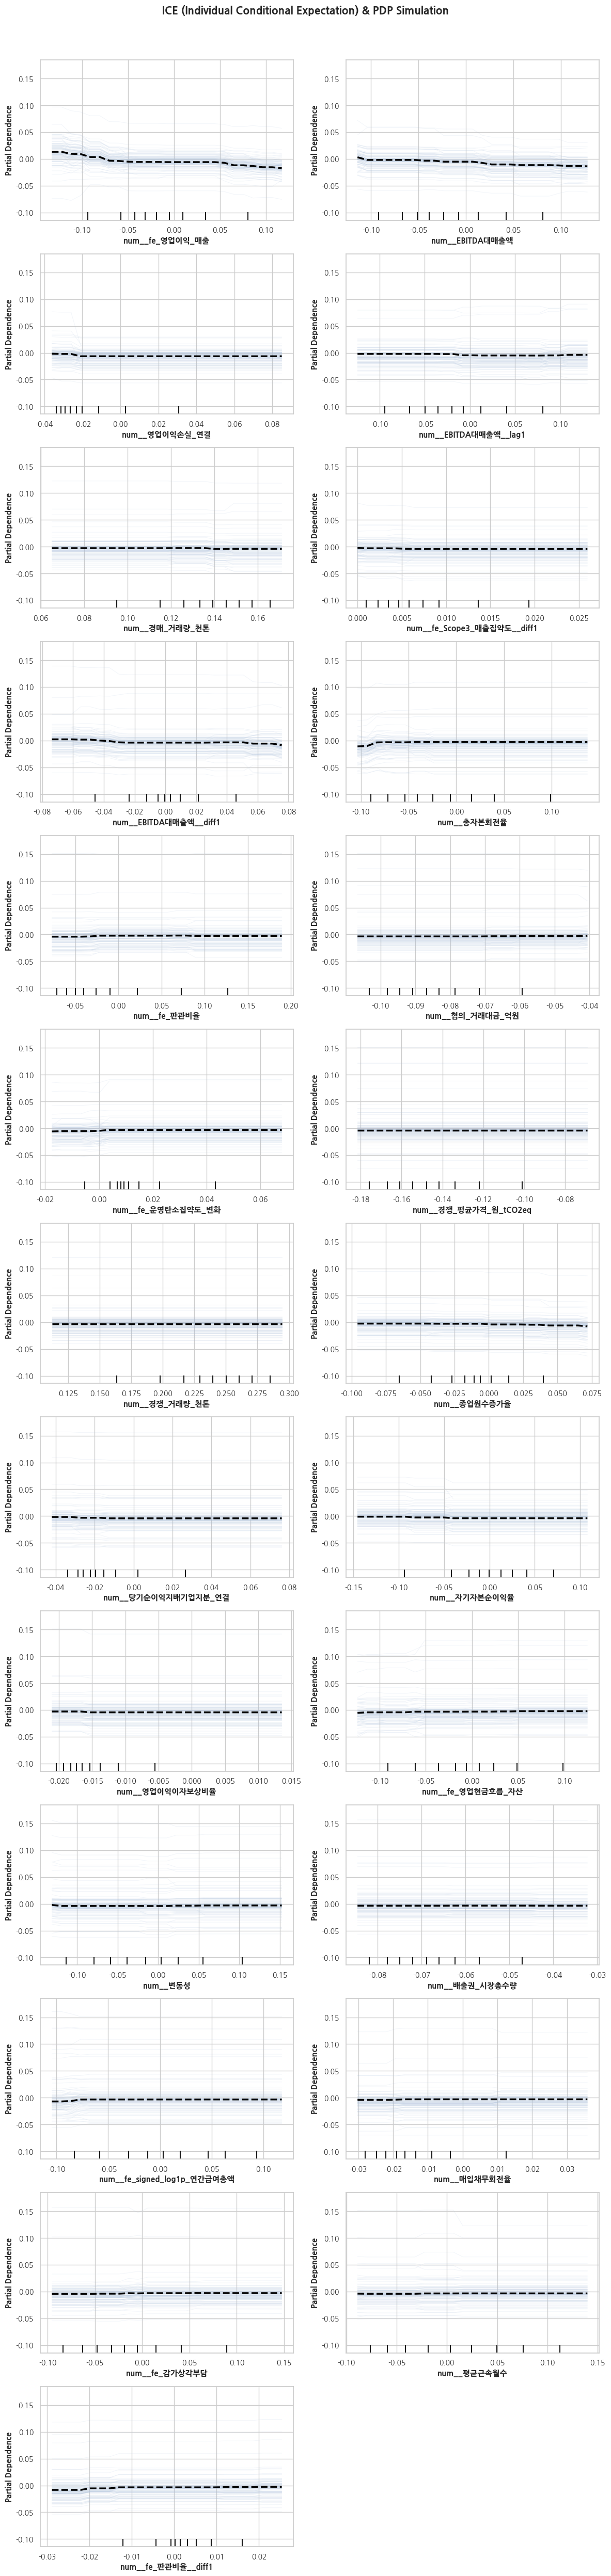


[Train Dataset Individual]: 2026-09-17 10:29:22.960883
Individual Explanation(1 Decision Plot -> 1 Force Plot -> 1000 Force Plot)...
Visualizing random index: 4876


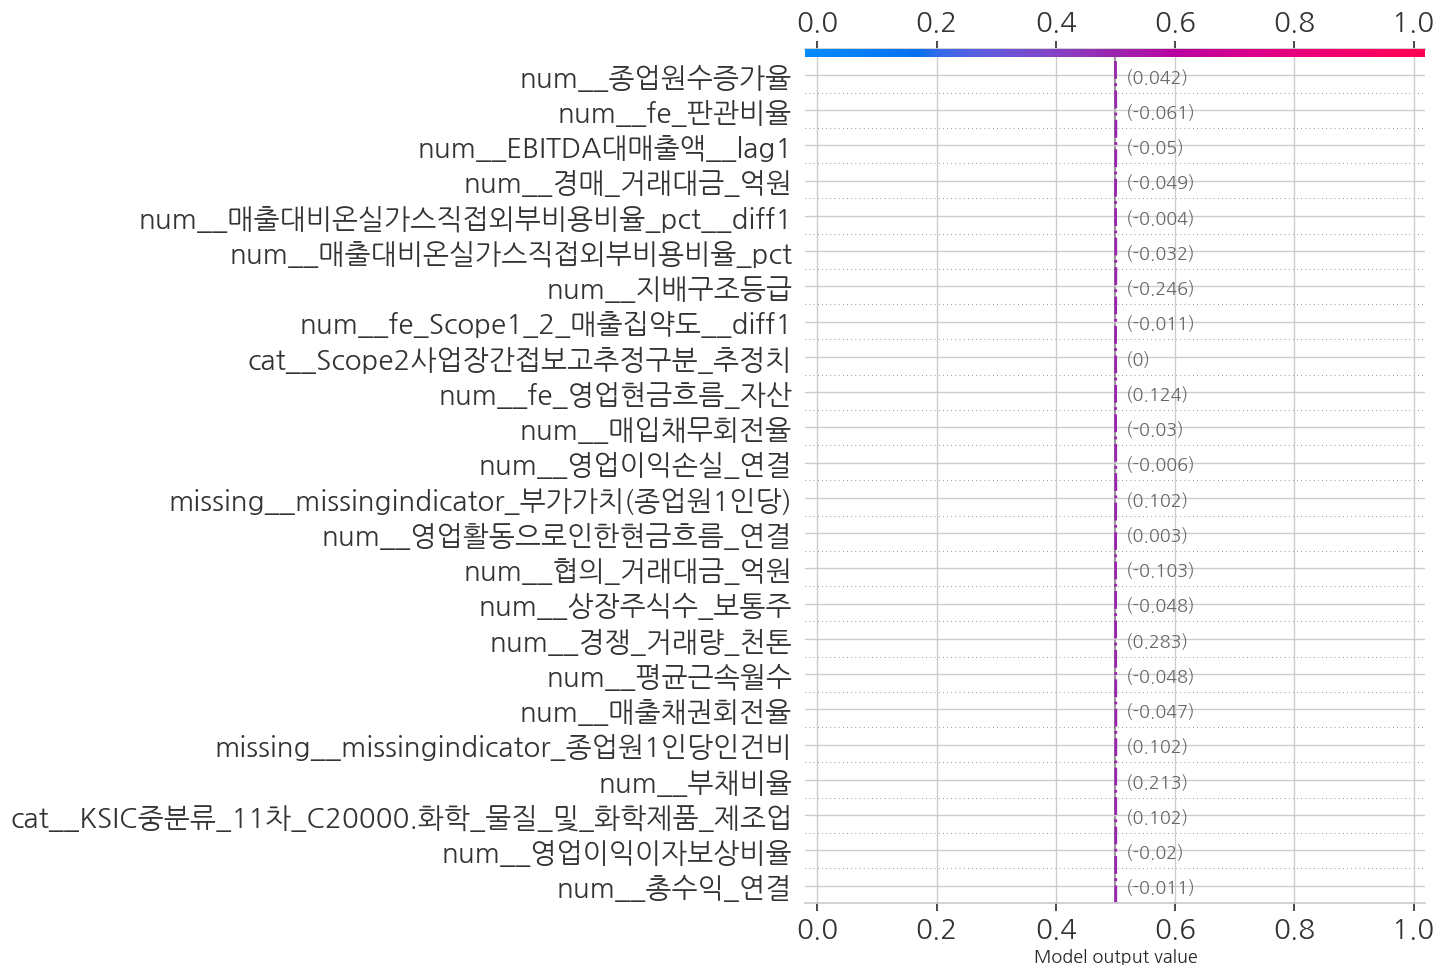


[Test Dataset Individual]: 2026-09-17 10:29:23.105155
Individual Explanation(1 Decision Plot -> 1 Force Plot -> 1000 Force Plot)...
Visualizing random index: 462


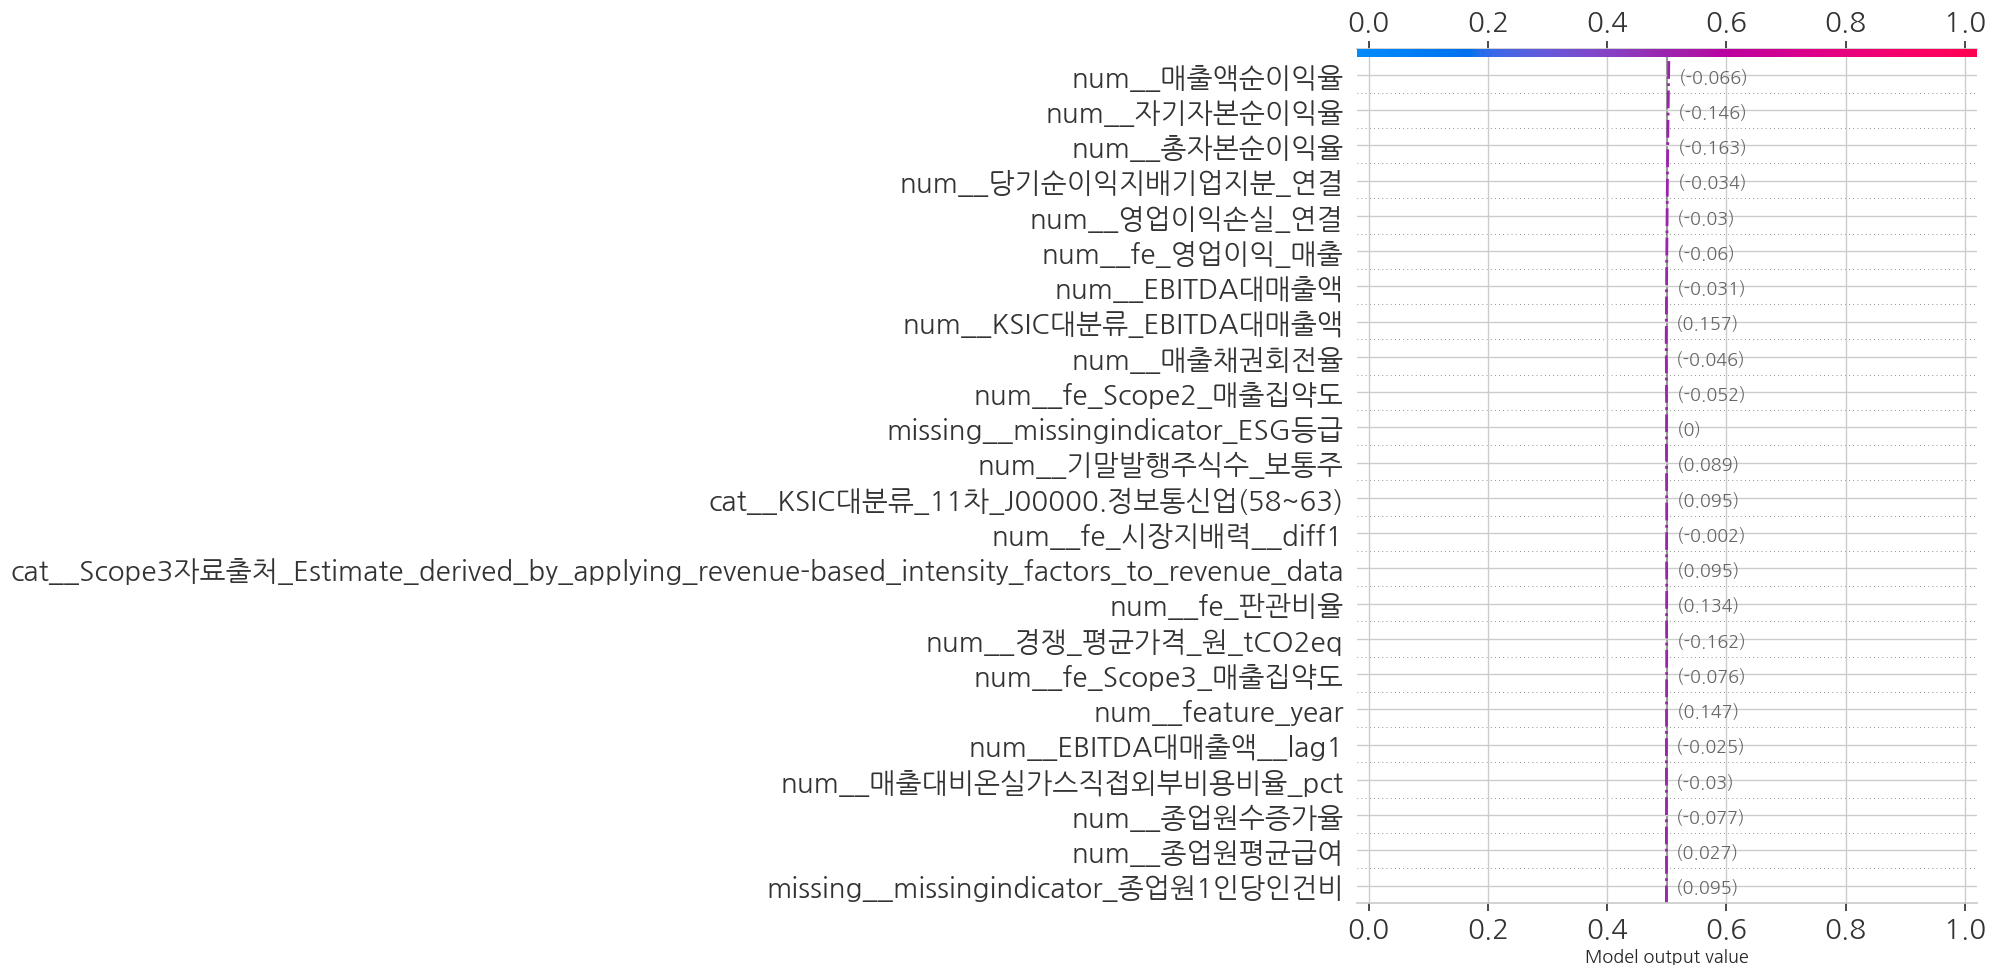

In [7]:
# Rename of Columns
X_selected = None
# df_domain_rename = pd.read_excel(os.path.join(FOLDER_GDM, '[Rename_20251228].xlsx'), sheet_name='Features_SI')
# df_domain_rename = {i[0]:i[1] for i in df_domain_rename[['변수설명(한글)', '변수설명(영어)']].values}
# if LANGUAGE == 'kr':
#     X_selected = [col for col in X_colname if col in list(df_domain_rename.keys())]
# else:
#     X_selected = [df_rename[col] for col in X_colname if col in list(df_domain_rename.keys())]

# SHAP 실행
explanation_SHAP(
    model=BEST_MODEL, 
    X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test,
    X_colname=X_colname, X_selected=X_selected,
    interaction=INTERACTION,
    interaction_samples=INTERACTION_SAMPLES,
    interaction_batch=INTERACTION_BATCH,
    max_display=X_TOP_DISPLAY-25,
)


# Group Analysis

In [ ]:
# 연가구소득
target_group = 'phase'
groups = {'Phase2': 2, 'Phase3': 3, 'Phase4':4}
# key_features = [
#     'Felt unable to carry on/do anything',
#     'Satisfaction with family life',
#     'Family life causes me stress',
#     'Energy bill discount/subsidy (electricity, gas, etc.)', # 또는 'Energy bill discount/subsidy'
#     'Felt lonely',
#     'Everything felt difficult',
#     'Satisfaction with relationship with children',
#     'Satisfaction with job'
# ]
key_features=None

df_fairness = evaluation_class_GroupFairness(
    best_model=best_model,
    target_col=target_group,
    groups_dict=groups,
    X_test=X_test, Y_test=Y_test, X_colname=X_colname,
    scaler_dict=scaler
)

df_comparison = explanation_SHAP_groupcomparing(
    target_col=target_group,
    groups_dict=groups,
    X_train=X_train, X_test=X_test,
    X_colname=X_colname,
    scaler_dict=scaler,
    best_algo=best_algo,
    max_display=10,
    save_csv=True,
    target_features=key_features
)

In [ ]:
# 연가구소득
target_group = 'vintage_bucket'
groups = {'Q3b~Q4A': 1, 'Q1': 2, 'Q2':3, 'Q3':4}
# key_features = [
#     'Felt unable to carry on/do anything',
#     'Satisfaction with family life',
#     'Family life causes me stress',
#     'Energy bill discount/subsidy (electricity, gas, etc.)', # 또는 'Energy bill discount/subsidy'
#     'Felt lonely',
#     'Everything felt difficult',
#     'Satisfaction with relationship with children',
#     'Satisfaction with job'
# ]
key_features=None

df_fairness = evaluation_class_GroupFairness(
    best_model=best_model,
    target_col=target_group,
    groups_dict=groups,
    X_test=X_test, Y_test=Y_test, X_colname=X_colname,
    scaler_dict=scaler
)

df_comparison = explanation_SHAP_groupcomparing(
    target_col=target_group,
    groups_dict=groups,
    X_train=X_train, X_test=X_test,
    X_colname=X_colname,
    scaler_dict=scaler,
    best_algo=best_algo,
    max_display=10,
    save_csv=True,
    target_features=key_features
)

# Preprocessing Library

In [ ]:
### Date and Author: 20260916, Kyungwon Kim ###
def preprocessing_CarbonFinance(
    df_raw,
    year_min=None, year_max=None,
    industry_filter=None,
    Y_colname='target__EBITDA대매출액_t1',
    firm_id_col='meta__종목코드',
    feature_year_col='meta__feature_year',
    target_year_col='meta__target_year',
    drop_firm_dummies=True,
    drop_meta_cols=True,
    create_lags=True,
    lag_features=None,
    X_delete=None
):
    """
    탄소-ESG-재무 데이터셋의 패널 구조 정합, 동태적 시차 변수 생성 및 누수 방지 전처리 함수
    
    Returns:
        df_prep (pd.DataFrame): 전처리 완료된 데이터프레임
        YEAR_COLNAME (str): Time-split의 기준이 되는 컬럼명
    """
    start_time = time.time()
    df = df_raw.copy()
    print("\n" + "="*60)
    print(" [PHASE 1] Starting Domain-Specific Preprocessing (Carbon & ESG Finance)")
    print(f" Initial Shape: {df.shape}")
    print("="*60)

    # 1. 시계열 패널 정렬 (종목코드, 피처연도 기준 정렬 필수)
    if firm_id_col in df.columns and feature_year_col in df.columns:
        print(f"▶ Sorting Panel: By [{firm_id_col}] & [{feature_year_col}]")
        df = df.sort_values(by=[firm_id_col, feature_year_col]).reset_index(drop=True)

    # 2. 기간 필터링 (Target Year 기준)
    if target_year_col in df.columns:
        if year_min is not None:
            df = df[df[target_year_col] >= year_min]
        if year_max is not None:
            df = df[df[target_year_col] <= year_max]
        print(f"▶ Target Year Filter: {year_min} ~ {year_max} (Remaining Rows: {len(df):,})")

    # 3. 특정 산업군 필터링 (필요 시)
    if industry_filter is not None:
        target_ind_cols = [c for c in df.columns if any(ind in c for ind in industry_filter)]
        if target_ind_cols:
            ind_mask = df[target_ind_cols].sum(axis=1) > 0
            df = df[ind_mask].copy()
            print(f"▶ Industry Filter Applied: {industry_filter} (Remaining Rows: {len(df):,})")

    # 4. 가설 A, B 검증을 위한 동태적 패널 변수 생성 (Lag-1 및 1년 변화량 Diff-1)
    if create_lags and firm_id_col in df.columns:
        if lag_features is None:
            # 기본 권장 핵심 가설 변수군
            lag_features = [
                # [가설 A: 탄소/배출권 리스크]
                'num__fe_배출권_부족비율',
                'num__fe_배출권_잠재탄소비용_원',
                'num__매출대비온실가스직접외부비용비율_pct',
                'num__fe_Scope1_2_매출집약도',
                'num__fe_Scope3_매출집약도',
                # [가설 B: 사회공헌 완충 및 인적자본]
                'num__fe_signed_log1p_기부금_원',
                'num__사회등급',
                'num__환경등급',
                'num__노동생산성',
                # [운영/조절 변수]
                'num__EBITDA대매출액',
                'num__fe_시장지배력',
                'num__fe_재고자산비중',
                'num__fe_판관비율'
            ]
        
        valid_lag_cols = [c for c in lag_features if c in df.columns]
        print(f"\n▶ Generating Lag-1 ($t-1$) & Diff-1 ($\Delta$) for {len(valid_lag_cols)} Features...")
        for col in valid_lag_cols:
            df[f'{col}__lag1'] = df.groupby(firm_id_col)[col].shift(1)
            df[f'{col}__diff1'] = df[col] - df[f'{col}__lag1']
        print(f"   ▷ Shape after Lag Generation: {df.shape}")

    # 5. 개별 종목 더미 제거 (트리 모델 암기 및 과적합 방지)
    if drop_firm_dummies:
        firm_dummy_cols = [c for c in df.columns if c.startswith('cat__종목코드_')]
        if firm_dummy_cols:
            df = df.drop(columns=firm_dummy_cols)
            print(f"▶ Dropped Individual Firm Dummies: {len(firm_dummy_cols)} columns dropped")

    # 6. 불필요한 메타 컬럼 정리 (target_year_col은 modeling split을 위해 보존)
    if drop_meta_cols:
        meta_to_drop = [c for c in df.columns if c.startswith('meta__') and c != target_year_col]
        df = df.drop(columns=meta_to_drop)
        print(f"▶ Cleaned Unused Meta Columns: {meta_to_drop}")

    # 7. 사용자 정의 추가 삭제 변수 (X_delete)
    if X_delete is not None:
        user_drop = [c for c in X_delete if c in df.columns]
        df = df.drop(columns=user_drop)
        print(f"▶ Dropped User-specified Columns (X_delete): {len(user_drop)} columns")

    YEAR_COLNAME = target_year_col
    print(f"\nCompleted Domain Preprocessing in {time.time()-start_time:.2f}s")
    print(f"Final Data Shape: {df.shape} | Assigned YEAR_COLNAME: '{YEAR_COLNAME}'\n")

    return df, YEAR_COLNAME